In [ ]:
import pandas as pd

df = pd.read_csv("data\processed\clean_prs.csv")
df.head()

,pr_id,repo_name,pr_number,title,body_len,user_login,user_type,created_datetime,closed_datetime,merged_datetime,...,commits,additions,deletions,changed_files,repo_language,repo_stars,repo_forks,is_fpt,keyword,is_merged
0,1217900573,nduybao/Train,1,prj301,0,ThanhPhong31,User,2023-01-26 13:49:23,2023-01-26 13:49:38,2023-01-26 13:49:38,...,1,3900,0,41,Java,0,0,1,PRJ301,1
1,1285249723,Henrily041103/PRJ301_SP2023,18,https://github.com/Henrily041103/PRJ301_SP2023...,0,wave-npa,User,2023-03-22 05:26:17,2023-03-22 06:02:53,2023-03-22 06:02:53,...,2,45,38,8,Java,0,3,1,PRJ301,1
2,1476177616,NoFearTeam2023/FPT-Capstone-UpReach-Project,36,Ha/fe,0,hoanganh1810tx,User,2023-08-15 16:34:46,2023-08-15 16:35:16,2023-08-15 16:35:16,...,2,38,14,5,JavaScript,0,0,1,Capstone FPT,1
3,1478047761,NoFearTeam2023/FPT-Capstone-UpReach-Project,39,Be hieu update,0,quanqhieu07,User,2023-08-16 20:39:13,2023-08-17 13:16:34,NaN,...,3,466,301,5,JavaScript,0,0,1,Capstone FPT,0
4,1479032519,NoFearTeam2023/FPT-Capstone-UpReach-Project,41,Be hieu update,0,quanqhieu07,User,2023-08-17 13:17:04,2023-08-17 14:43:44,2023-08-17 14:43:44,...,4,464,301,5,JavaScript,0,0,1,Capstone FPT,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pr_id                1771 non-null   int64  
 1   repo_name            1771 non-null   object 
 2   pr_number            1771 non-null   int64  
 3   title                1771 non-null   object 
 4   body_len             1771 non-null   int64  
 5   user_login           1771 non-null   object 
 6   user_type            1771 non-null   object 
 7   created_datetime     1771 non-null   object 
 8   closed_datetime      1771 non-null   object 
 9   merged_datetime      1647 non-null   object 
 10  created_hour         1771 non-null   int64  
 11  created_day_of_week  1771 non-null   int64  
 12  duration_minutes     1771 non-null   float64
 13  duration_hours       1771 non-null   float64
 14  comments             1771 non-null   int64  
 15  review_comments      1771 non-null   i

#### Data Preprocessing

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Drop irrelevant & leakage columns
df_processed = df.drop(columns=[
    'pr_id', 'repo_name', 'pr_number', 'title', 'body_len', 'user_type', 'user_login', 'merged_datetime',
    'created_datetime', 'closed_datetime',
    'duration_minutes', 'duration_hours'
    ])

# Identify categorical columns for one-hot encoding
categorical_cols = ['repo_language', 'keyword']

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols)

### Harmonizing Data Splits for Consistent Model Training and Evaluation

In [35]:
X_fpt = df_processed[df_processed['is_fpt'] == 1].drop(columns = ["is_merged"])
y_fpt = df_processed[df_processed['is_fpt'] == 1]["is_merged"]

X_fpt_train, X_fpt_test, y_fpt_train, y_fpt_test = train_test_split(X_fpt, y_fpt, test_size=0.3, random_state=42, stratify=y_fpt)
print(f"FPT Training data shape: {X_fpt_train.shape}")
print(f"FPT Training target shape: {y_fpt_train.shape}")
print()

print(f"FPT Test data shape: {X_fpt_test.shape}")
print(f"FPT Test target shape: {y_fpt_test.shape}")
print()

print("Class distribution in FPT Training set:")
print(y_fpt_train.value_counts(normalize=True))
print()

print("Class distribution in FPT Test set:")
print(y_fpt_test.value_counts(normalize=True))

FPT Training data shape: (589, 31)
FPT Training target shape: (589,)

FPT Test data shape: (253, 31)
FPT Test target shape: (253,)

Class distribution in FPT Training set:
is_merged
1    0.923599
0    0.076401
Name: proportion, dtype: float64

Class distribution in FPT Test set:
is_merged
1    0.920949
0    0.079051
Name: proportion, dtype: float64


#### Gausian Anomaly Detection

In [36]:
from scipy.stats import multivariate_normal
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Separate 'normal' (is_merged = 1) and 'anomaly' (is_merged = 0) samples within X_fpt_train
X_normal_fpt_train = X_fpt_train[y_fpt_train == 1]
y_normal_fpt_train = y_fpt_train[y_fpt_train == 1]

X_anomaly_fpt_train = X_fpt_train[y_fpt_train == 0]
y_anomaly_fpt_train = y_fpt_train[y_fpt_train == 0]

# Split X_normal_fpt_train into 60% for training the Gaussian model and 40% for validation
X_train_normal_gaus, X_val_normal_gaus, y_train_normal_gaus, y_val_normal_gaus = train_test_split(
    X_normal_fpt_train, y_normal_fpt_train, test_size=0.1, random_state=42, stratify=y_normal_fpt_train
)

# Combine X_val_normal_gaus and X_anomaly_fpt_train to form the Gaussian validation set
X_val_gaus = pd.concat([X_val_normal_gaus, X_anomaly_fpt_train])
y_val_gaus = pd.concat([y_val_normal_gaus, y_anomaly_fpt_train])

print(f"Gaussian Training set (normal samples, FPT only): {X_train_normal_gaus.shape[0]} samples")
print(f"Gaussian Validation set (normal and anomaly, FPT only): {X_val_gaus.shape[0]} samples")


Gaussian Training set (normal samples, FPT only): 489 samples
Gaussian Validation set (normal and anomaly, FPT only): 100 samples


In [37]:
# Recalculate mu and sigma with the new Gaussian training data
mu_gaus = X_train_normal_gaus.mean().values
sigma_gaus = X_train_normal_gaus.cov().values

# Create a multivariate Gaussian distribution object
gaus_dist = multivariate_normal(mean=mu_gaus, cov=sigma_gaus, allow_singular=True)

# Calculate the probability density for each sample in the Gaussian validation set
p_val_gaus = gaus_dist.pdf(X_val_gaus)

# Find the best epsilon for the Gaussian model (on its validation set)
thresholds_gaus = np.sort(p_val_gaus)
best_epsilon_gaus = 0
best_f1_gaus = -1

for epsilon_gaus in thresholds_gaus:
    y_pred_val_mapped_gaus = (p_val_gaus >= epsilon_gaus).astype(int)
    precision_gaus, recall_gaus, f1_gaus, _ = precision_recall_fscore_support(y_val_gaus, y_pred_val_mapped_gaus, average='binary', pos_label=0, zero_division=0) # return report for pos_label class, return zero_division when divide by zero

    if f1_gaus > best_f1_gaus:
        best_f1_gaus = f1_gaus
        best_epsilon_gaus = epsilon_gaus

print(f"\nBest epsilon (threshold) for Gaussian model: {best_epsilon_gaus}")
print(f"Best F1-score (for anomaly class 0) for Gaussian model: {best_f1_gaus}")


Best epsilon (threshold) for Gaussian model: 2.6647106944524253e-09
Best F1-score (for anomaly class 0) for Gaussian model: 0.6511627906976745


Gaussian Test set (FPT only): 253 samples

Classification Report (Gaussian Anomaly Detection on FPT Test Set):

              precision    recall  f1-score   support

  Not Merged       0.08      0.80      0.15        20
      Merged       0.93      0.24      0.39       233

    accuracy                           0.29       253
   macro avg       0.51      0.52      0.27       253
weighted avg       0.87      0.29      0.37       253




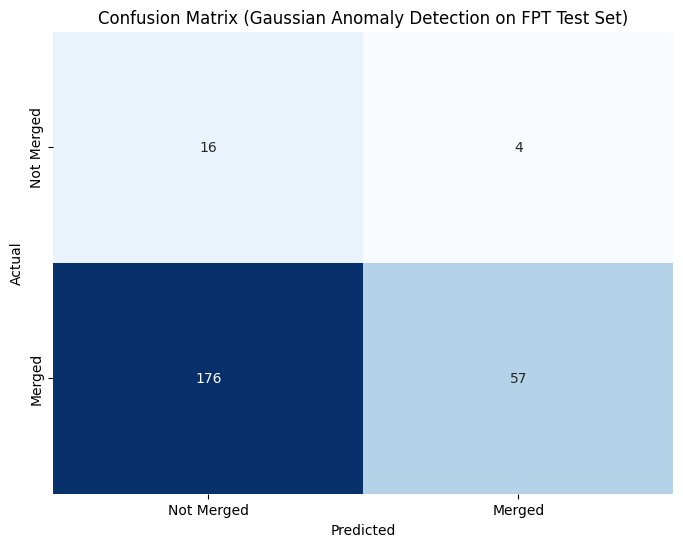

In [45]:
# Make test set for final Gaussian evaluation
print(f"Gaussian Test set (FPT only): {X_fpt_test.shape[0]} samples")

# Make final predictions with the best threshold on the global FPT test set
p_test_gaus = gaus_dist.pdf(X_fpt_test) # Calculate probabilities on the global FPT test set
y_pred_gaus = (p_test_gaus >= best_epsilon_gaus).astype(int)

# Print classification report for Gaussian model on the FPT test set
print("\nClassification Report (Gaussian Anomaly Detection on FPT Test Set):\n")
print(classification_report(y_fpt_test, y_pred_gaus, target_names=['Not Merged', 'Merged']))
print()

# Compute and visualize confusion matrix for Gaussian model
cm_gaus = confusion_matrix(y_fpt_test, y_pred_gaus)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gaus, annot=True, fmt='d', cmap='Blues', cbar=False, # annot = True to visualize numbe
            xticklabels=['Not Merged', 'Merged'],                   # fmt = 'd' to visualize decimal integer
            yticklabels=['Not Merged', 'Merged'])                   # cbar = False to not visualize color bar
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Gaussian Anomaly Detection on FPT Test Set)')
plt.show()

#### Random Forest


--- Training Random Forest Model (FPT Data Split) ---
Training data shape: (589, 31)
Test data shape: (253, 31)

Classification Report (Random Forest, FPT Data Split):

              precision    recall  f1-score   support

  Not Merged       0.75      0.30      0.43        20
      Merged       0.94      0.99      0.97       233

    accuracy                           0.94       253
   macro avg       0.85      0.65      0.70       253
weighted avg       0.93      0.94      0.92       253




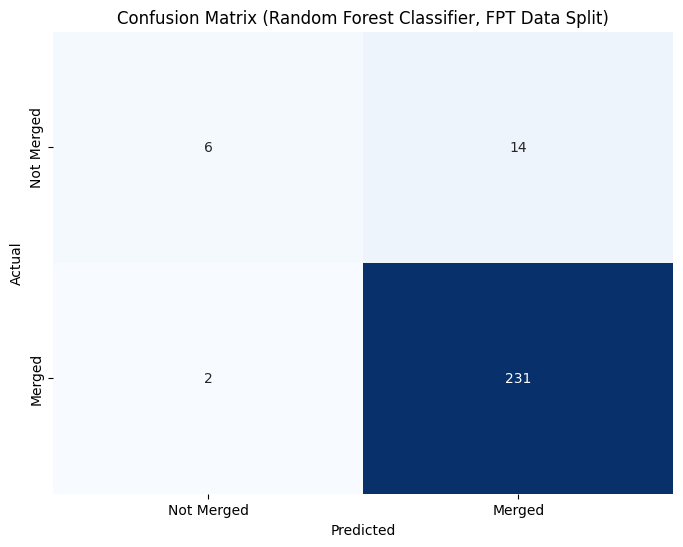

In [41]:
print("\n--- Training Random Forest Model (FPT Data Split) ---")

print(f"Training data shape: {X_fpt_train.shape}")
print(f"Test data shape: {X_fpt_test.shape}")

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_fpt_train, y_fpt_train)

y_pred_rf = rf_model.predict(X_fpt_test)

# Print classification report
print("\nClassification Report (Random Forest, FPT Data Split):\n")
print(classification_report(y_fpt_test, y_pred_rf, target_names=['Not Merged', 'Merged']))
print()

# Compute confusion matrix
cm_rf = confusion_matrix(y_fpt_test, y_pred_rf)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest Classifier, FPT Data Split)')
plt.show()

#### Voting classifier


--- Ensemble Model (Average Voting on FPT Data) ---

Classification Report (Ensemble - Average Voting on FPT Data):

              precision    recall  f1-score   support

  Not Merged       0.09      0.90      0.17        20
      Merged       0.97      0.24      0.39       233

    accuracy                           0.30       253
   macro avg       0.53      0.57      0.28       253
weighted avg       0.90      0.30      0.37       253




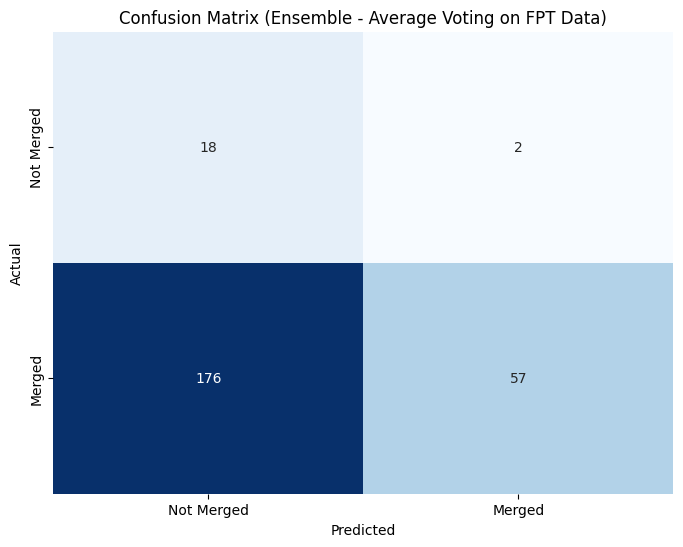

In [42]:
# Simple Majority Voting Ensemble (Average of binary predictions)
ensemble_predictions_avg = ((y_pred_gaus + y_pred_rf) / 2 > 0.5).astype(int)

print("\n--- Ensemble Model (Average Voting on FPT Data) ---")
print("\nClassification Report (Ensemble - Average Voting on FPT Data):\n")
print(classification_report(y_fpt_test, ensemble_predictions_avg, target_names=['Not Merged', 'Merged']))
print()

cm_ensemble_avg = confusion_matrix(y_fpt_test, ensemble_predictions_avg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble_avg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Ensemble - Average Voting on FPT Data)')
plt.show()

#### Random forest with SMOTE


--- Random Forest after Oversampling (FPT Data) ---
Original training data shape (FPT only): (589, 31)
Original target distribution (FPT only):
is_merged
1    0.923599
0    0.076401
Name: count, dtype: float64

Resampled training data shape (FPT only): (1088, 31)
Resampled target distribution (FPT only):
is_merged
1    544
0    544
Name: count, dtype: int64

Classification Report (Random Forest with Oversampling on FPT Data):

              precision    recall  f1-score   support

  Not Merged       0.38      0.40      0.39        20
      Merged       0.95      0.94      0.95       233

    accuracy                           0.90       253
   macro avg       0.66      0.67      0.67       253
weighted avg       0.90      0.90      0.90       253




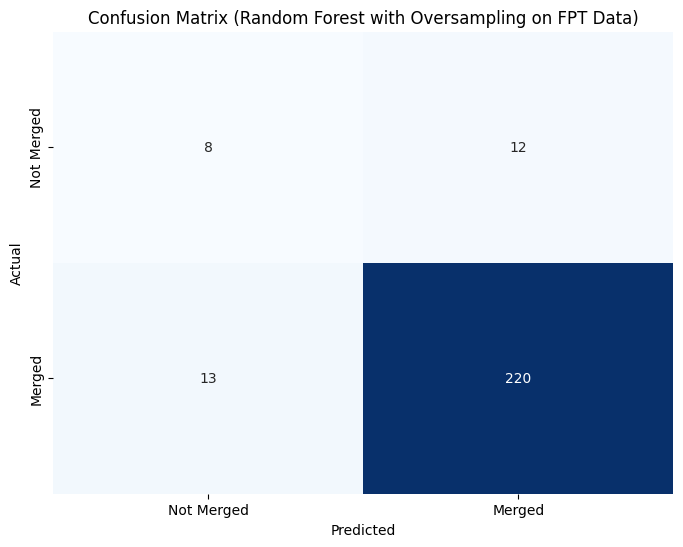

In [43]:
from imblearn.over_sampling import SMOTE

print("\n--- Random Forest after Oversampling (FPT Data) ---")

# Before oversampling
print(f"Original training data shape (FPT only): {X_fpt_train.shape}")
print(f"Original target distribution (FPT only):\n{y_fpt_train.value_counts() / len(y_fpt_train)}")

# Initialize SMOTE for the minority class (is_merged = 0)
sm = SMOTE(random_state=42)

# Apply SMOTE to the FPT training data
X_train_res, y_train_res = sm.fit_resample(X_fpt_train, y_fpt_train)

# After oversampling
print(f"\nResampled training data shape (FPT only): {X_train_res.shape}")
print(f"Resampled target distribution (FPT only):\n{y_train_res.value_counts()}")

# Retrain Random Forest Classifier on the oversampled data
rf_model_oversampled = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_oversampled.fit(X_train_res, y_train_res)

# Make predictions on the FPT test set (no oversampling on test set)
y_pred_oversampled = rf_model_oversampled.predict(X_fpt_test)

# Print classification report
print("\nClassification Report (Random Forest with Oversampling on FPT Data):\n")
print(classification_report(y_fpt_test, y_pred_oversampled, target_names=['Not Merged', 'Merged']))
print()

# Compute confusion matrix
cm_oversampled = confusion_matrix(y_fpt_test, y_pred_oversampled)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_oversampled, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest with Oversampling on FPT Data)')
plt.show()

#### SHAP Interpretation

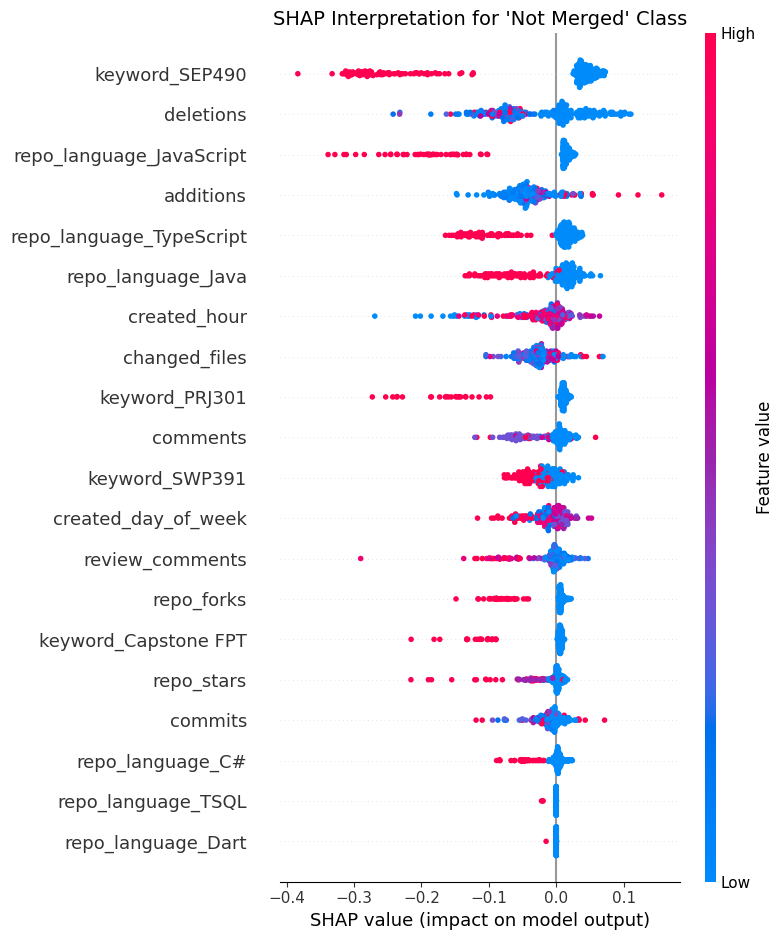

In [52]:
import shap

explainer = shap.TreeExplainer(rf_model_oversampled)
shap_values = explainer.shap_values(X_fpt_test)

shap_not_merge = shap_values[..., 0] if len(shap_values.shape) > 2 else shap_values[0]

# Plot for 'Not Merged' class
plt.figure(figsize=(7, 6))
shap.summary_plot(shap_not_merge, X_fpt_test, show=False)
plt.title("SHAP Interpretation for 'Not Merged' Class", fontsize=14)
plt.tight_layout()
plt.show()

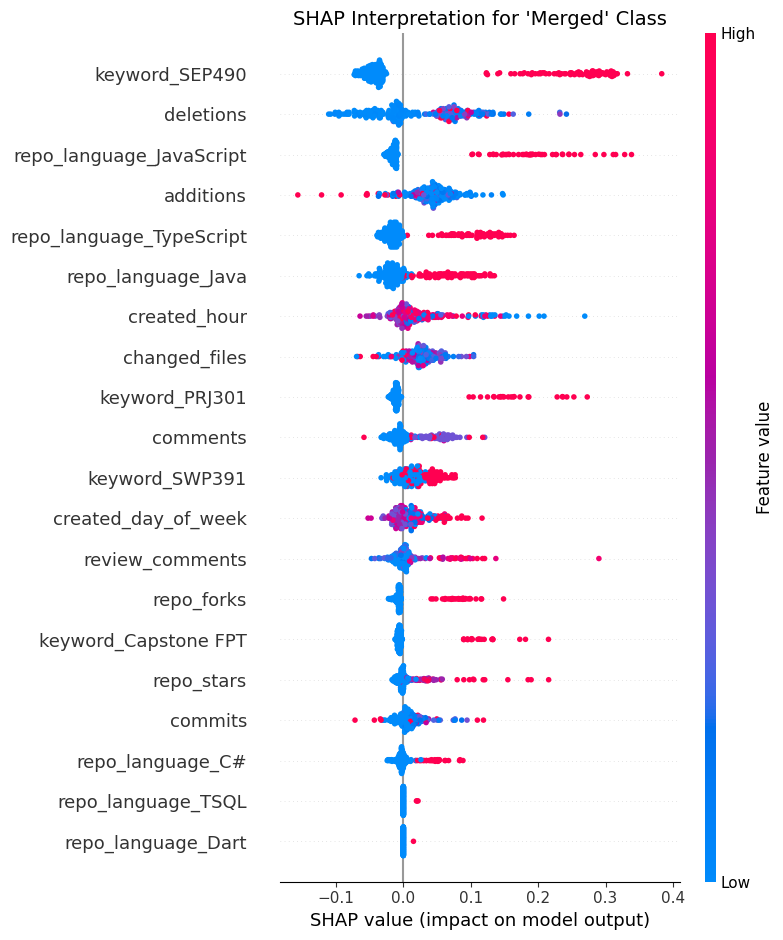

In [53]:
shap_merge = shap_values[..., 1] if len(shap_values.shape) > 2 else shap_values[1]

# Plot for 'Not Merged' class
plt.figure(figsize=(7, 6))
shap.summary_plot(shap_merge, X_fpt_test, show=False)
plt.title("SHAP Interpretation for 'Merged' Class", fontsize=14)
plt.tight_layout()
plt.show()